In [1]:
%run ~/analysisLibraries

In [2]:
%matplotlib inline

In [3]:
%load_ext rpy2.ipython

## Read data containing all necessary scores and relevant genes calculated in the previous notebook

In [4]:
adata = sc.read('./write/SDA_object_100comps.h5ad')

component can be changed using the software papermill to execute notebooks in the workflow

In [5]:
comp=0

In [6]:
# Parameters
comp = 94


## Open SDA matrices

In [7]:
A = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/A', sep=' ', header=None)
#B is only for multi-tissues tensor
#B = pd.read_csv('SDA/CELLS_sctransform_onematrix_data/it2000/B1', sep=' ', header=None)
X = pd.read_csv('ALLDATA_scaled_onematrix_data_100comps/it2000/X1', sep=' ', header=None)

$A$ contains the score of each cell in the components. This score can be used as a "soft clustering" once it is normalized. We will try to do that in the notebook that follows this one. 

In [8]:
A.shape

(10548, 100)

In [9]:
A.head()

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,0.237044,-0.444741,-0.521709,-0.421176,-0.191632,-0.039443,-0.011519,0.313026,-0.017442,-0.014353,...,-0.713952,0.084345,0.325848,0.577062,-0.704971,-0.307896,0.102466,-0.919935,-0.196817,-1.101270
1,0.411126,-0.113899,-0.404359,-0.412903,0.112982,-0.168036,-0.364643,0.746365,-0.003497,-0.242012,...,0.923655,-0.432896,0.018581,-0.329805,-0.004898,-0.298961,0.290554,0.328762,-0.211422,0.605521
2,-0.554124,-2.115210,0.572701,-0.509780,0.577237,-0.234850,0.450509,0.208679,0.177719,-0.164977,...,-0.382789,0.511820,0.686443,0.116738,-0.315359,-0.109686,1.740900,-0.937221,0.846761,0.562644
3,-0.258430,1.402740,1.303190,-0.759115,1.298820,-0.058847,-0.725280,-0.359907,0.306425,1.195000,...,-0.727815,0.416148,2.020470,-0.108066,-0.465147,-1.716540,0.712520,-0.855888,0.907461,0.266163
4,-0.338097,1.336100,-1.538940,0.907896,0.817900,1.415150,-0.130066,-0.545487,-0.755909,-0.912024,...,-1.259190,-0.325736,0.157799,1.454890,-0.115039,-0.391225,1.149520,0.961979,-0.198099,0.624347


In [10]:
#B

$X$ contains the loading of each gene in each component according to the spike-and-slab prior. The sign of the loading has to be considered together with the sign of the cell score to see if the resulting sign is positive (significant expression of gene) or negative (significant underexpression of gene)

In [11]:
X.columns = adata[:,(np.log(adata.var['variance-Cells'])>0)|(np.log(adata.var['variance-Nuclei']>-1))].var_names

In [12]:
X.shape

(100, 6276)

In [13]:
X.head()

,AURKAIP1,MRPL20,SSU72,LOC469457,GNB1,MORN1,RER1,MMEL1,ACTRT2,CCDC27,...,amplicon-chrX-FAM9A/B/C-6,amplicon-chrX-GAGE10-0,amplicon-chrX-LOC107966365-0,amplicon-chrX-LOC112206844-0,amplicon-chrX-LOC112206844-2,amplicon-chrX-LOC112206844-4,amplicon-chrX-LOC465705-2,amplicon-chrX-PAGE5-3,amplicon-chrX-SPANXN5-2,amplicon-chrX-SSX1/3/2B-15
0,-0.251518,-0.050381,-0.000772,-0.082587,-0.000094,-0.001789,-0.132522,0.000048,-0.053861,-0.035661,...,0.000333,0.000363,-0.000149,-0.036358,-0.000366,0.002521,-0.061503,0.000056,0.000141,0.006134
1,0.000395,0.000193,-0.000607,0.001750,0.000787,-0.001956,-0.000217,-0.000121,0.000535,-0.000017,...,0.066423,-0.000271,0.000069,0.029602,0.001012,0.000030,-0.000178,0.000639,-0.026457,0.000855
2,-0.000250,-0.000108,-0.000195,0.030246,0.000202,-0.001048,-0.000112,0.000151,-0.001854,-0.000145,...,-0.000141,0.001418,-0.000997,-0.000141,-0.039148,-0.000122,0.000968,-0.000012,-0.001109,0.000334
3,0.000423,-0.000399,-0.000322,0.002582,0.000288,0.000177,-0.000765,0.046786,0.000218,0.000263,...,-0.000404,0.000993,0.000137,0.000224,0.043691,-0.000044,0.000219,0.000187,0.000062,-0.000340
4,-0.000056,-0.000013,0.000059,-0.000223,0.033124,-0.000006,0.000276,-0.107145,0.000001,-0.051293,...,-0.034791,0.000032,0.061013,-0.000074,-0.000050,0.000003,0.000006,0.000007,-0.000034,-0.037562


## Some plots and measures about the specific components

#### UMAP of cell scores and batches

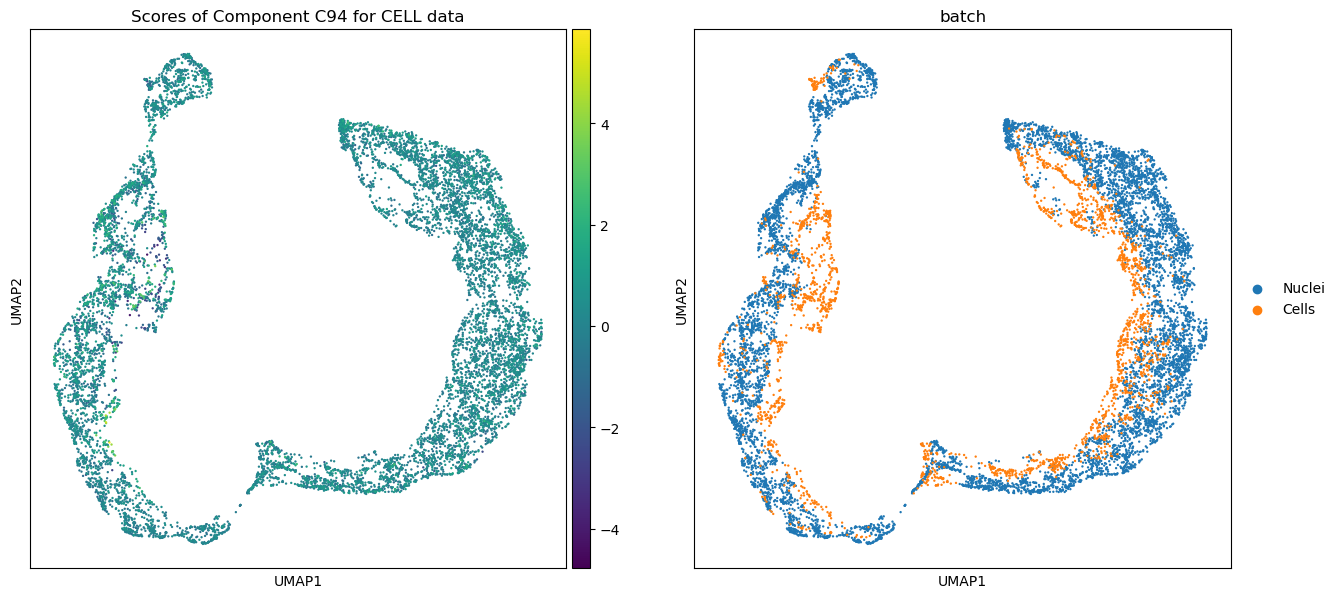

In [14]:
plt.rcParams['figure.figsize']=(7,7)
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}','batch'],
          title=f'Scores of Component C{comp} for CELL data')

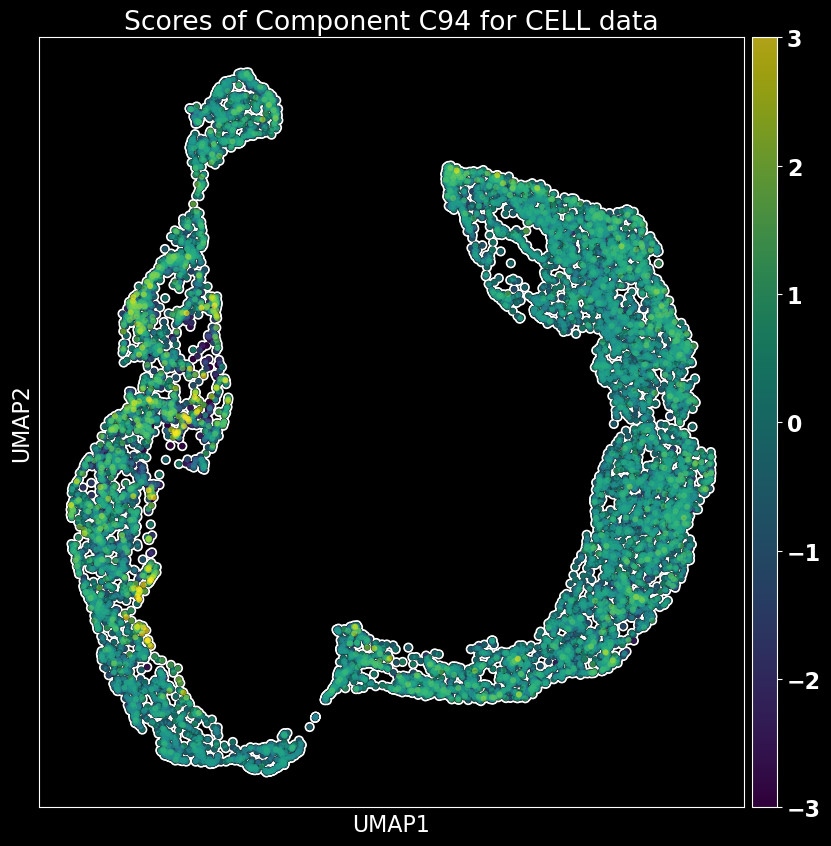

In [15]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True, outline_color=['white','black'],
          save=f'scores_C{comp}_dark.png', )

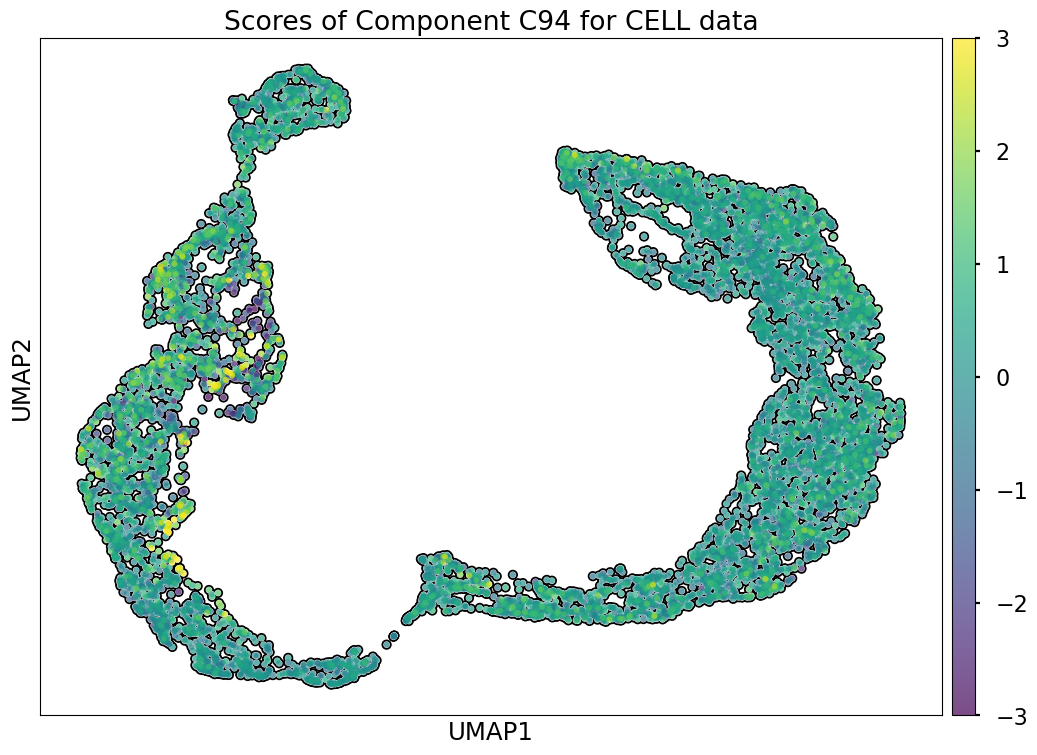

In [16]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'SDA_cellscore_C{comp}'], vmin=-3, vmax=3, 
          title=f'Scores of Component C{comp} for CELL data', size=75,
          add_outline=True,
          save=f'scores_C{comp}_white.png', )

In [17]:
try:
    IRRELEVANT=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['IRRELEVANT']
except Exception as e:
    IRRELEVANT=0
try:
    POSITIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['POSITIVE']
except Exception as e:
    POSITIVE=0
try:
    NEGATIVE=adata.obs[f'sda_cell_relevant_C{comp}'].value_counts()['NEGATIVE']
except Exception as e:
     NEGATIVE=0

In [18]:
onlyrelevant = np.array( adata.obs[f'sda_cell_relevant_C{comp}'].copy() )
onlyrelevant[onlyrelevant=='IRRELEVANT']=None
adata.obs[f'sda_cell_relevantonly_C{comp}'] = onlyrelevant

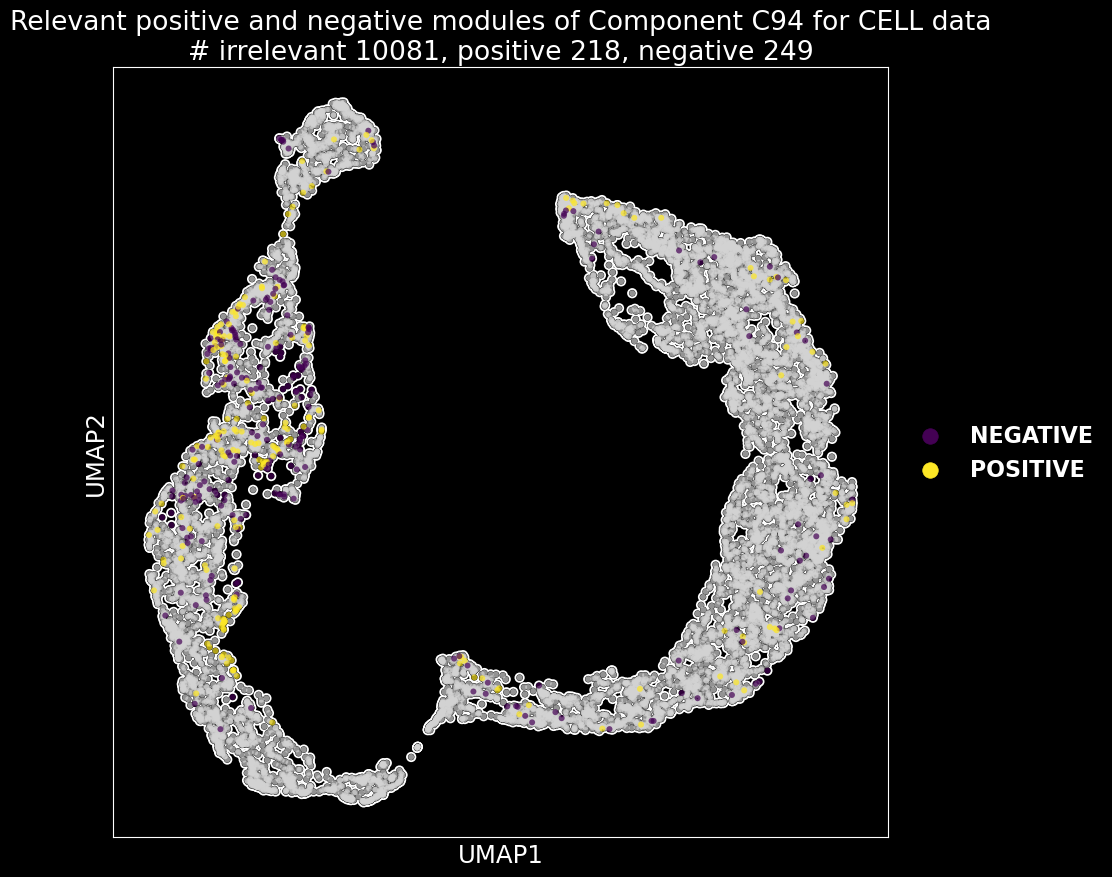

In [19]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('dark_background')
plt.rc('font', size=16, weight='bold')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data\n# irrelevant {IRRELEVANT}, positive {POSITIVE}, negative {NEGATIVE}', 
          size=75, add_outline=True, outline_color=['white','black'], palette='viridis',
          save=f'relevance_C{comp}_dark.png')

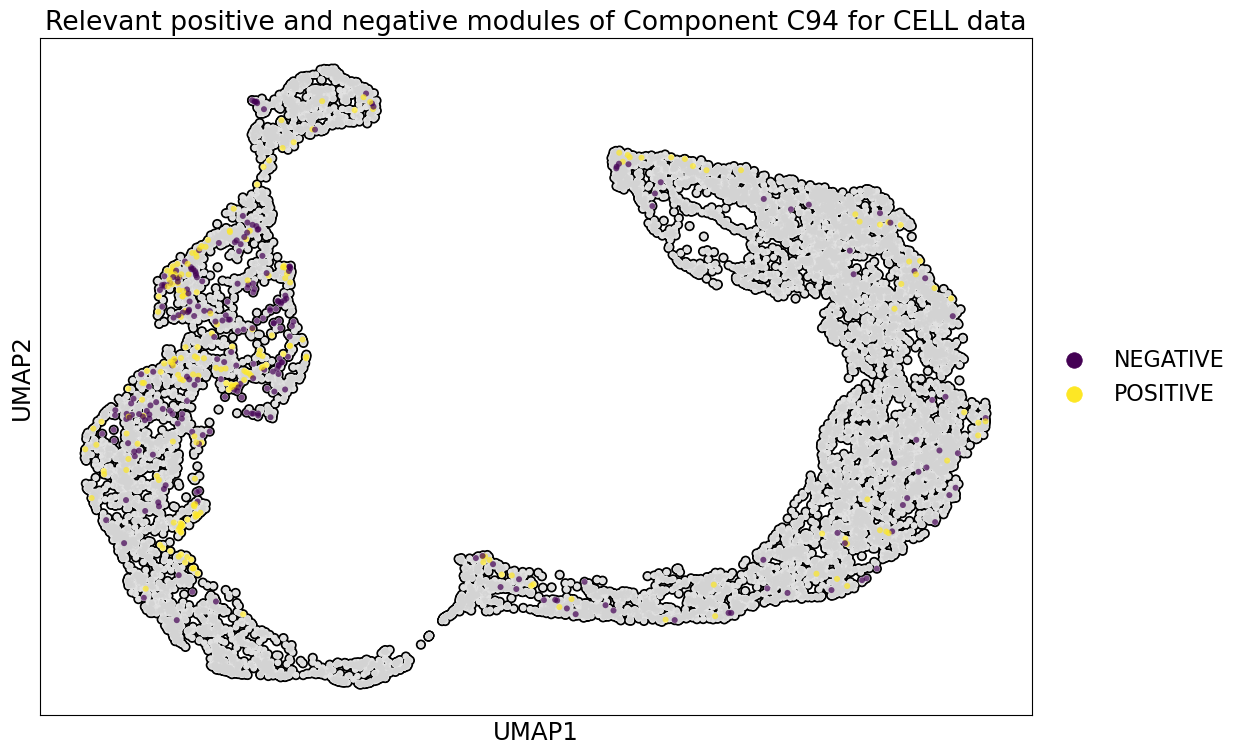

In [20]:
plt.rcParams['figure.figsize']=(10,10)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'sda_cell_relevantonly_C{comp}'], vmin=-3, vmax=3, na_in_legend=False, na_color='lightgray',
          title=f'Relevant positive and negative modules of Component C{comp} for CELL data', palette='viridis',
          size=75, add_outline=True,
          save=f'relevance_C{comp}_white.png')

### mean and std of positive and negative cell scores for each batch

In [21]:
score_cells = adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}']
score_nuclei = adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}']

In [22]:
print( 'Positive scores nuclei - mean:', np.mean(score_nuclei[score_nuclei>1.5]), 'var:', np.std(score_nuclei[score_nuclei>1.5])  )
print( 'Positive scores cells  - mean:', np.mean(score_cells[score_cells>2]), 'var:', np.std(score_cells[score_cells>2])  )

Positive scores nuclei - mean: 1.855011020408163 var: 0.34774230100728776
Positive scores cells  - mean: 2.828670422535211 var: 0.7302032251317295


In [23]:
print( 'Negative scores nuclei - mean:', np.mean(score_nuclei[score_nuclei<-1.5]), 'var:', np.std(score_nuclei[score_nuclei<-1.5])  )
print( 'Negative scores cells  - mean:', np.mean(score_cells[score_cells<-2]), 'var:', np.std(score_cells[score_cells<-2])  )

Negative scores nuclei - mean: -1.9217444705882352 var: 0.4345325319521195
Negative scores cells  - mean: -2.7255664556962027 var: 0.5839565006927845


### T-test to detect batch differences in a module

We check if positive/negative scores are specific for either cells or genes, so we can highlight that in our information output

In [24]:
import scipy

Two-sided test of positive scores of cells vs nuclei

In [25]:
scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])

Ttest_indResult(statistic=8.826571702072268, pvalue=1.4596295220701645e-18)

Two-sided test of negative scores of cells vs nuclei

In [26]:
scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

Ttest_indResult(statistic=-8.142291988682086, pvalue=4.767701327191911e-16)

Cells have more transcripts than nuclei and this is reflected in a bit higher/lower score in general, so we choose a strict threshold to avoid detecting batch differences where they are mostly due to technical causes

In [27]:
pos_stat, pos_p = scipy.stats.ttest_ind( score_cells[score_cells>0], score_nuclei[score_nuclei>0])
neg_stat, neg_p = scipy.stats.ttest_ind( score_cells[score_cells<0], score_nuclei[score_nuclei<0])

batch_effect_pos='No'
batch_effect_neg='No'

if np.abs(pos_stat) > 10:
    batch_effect_pos='Yes'
print(f'Positive module batch differences: {batch_effect_pos}')
    
if np.abs(neg_stat) > 10:
    batch_effect_neg='Yes'
print(f'Negative module batch differences: {batch_effect_neg}')

Positive module batch differences: No
Negative module batch differences: No


<Axes: xlabel='SDA_cellscore_C94', ylabel='Count'>

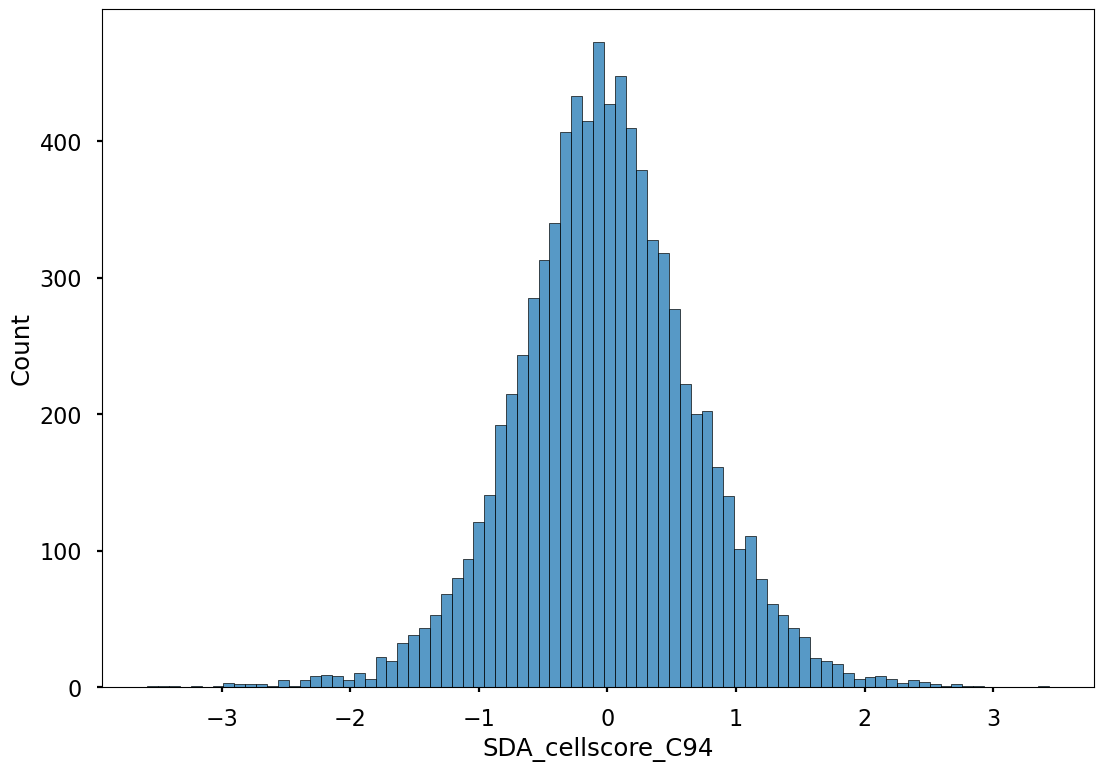

In [28]:
plt.rcParams['figure.figsize']=(6,6)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.histplot(adata[adata.obs['batch']=='Nuclei'].obs[f'SDA_cellscore_C{comp}'])

<Axes: xlabel='SDA_cellscore_C94', ylabel='Count'>

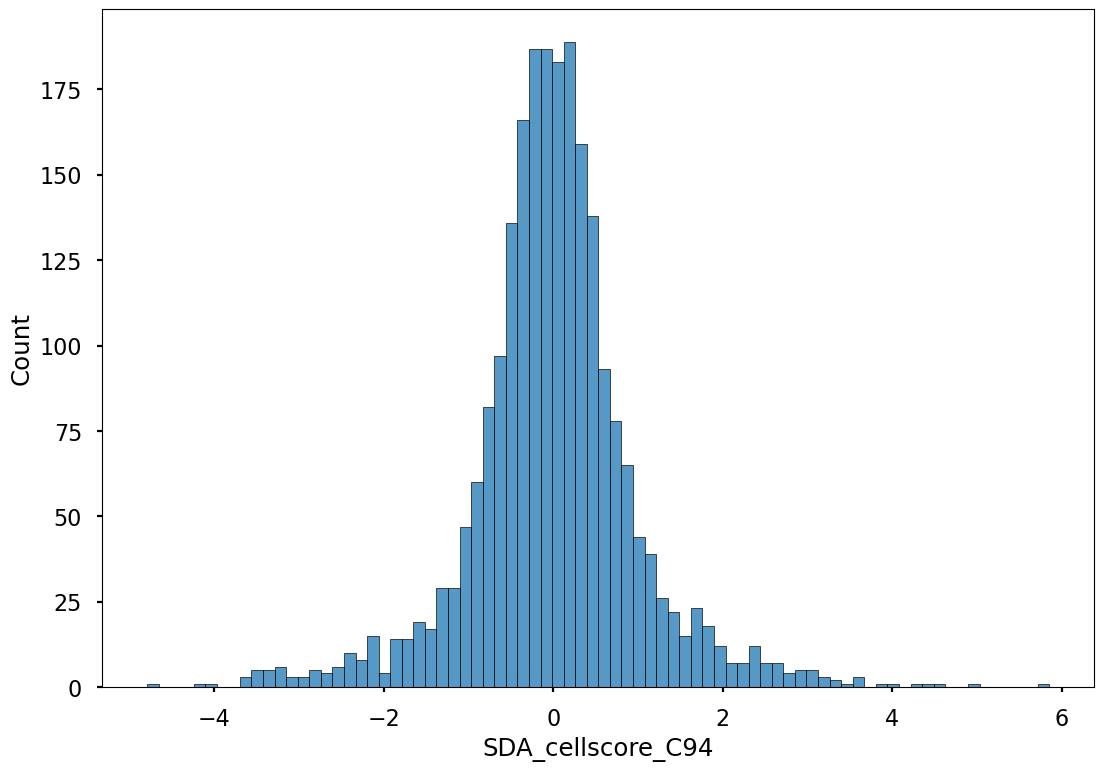

In [29]:
sns.histplot(adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'])

Genes significant for components (whole list printed to easy copy-pase for onlyne databases):

In [30]:
print(f'Genes significant for positive C{comp}:', adata[:,adata.var[f'sda_pos_C{comp}']].shape[1])

Genes significant for positive C94: 300


In [31]:
for i in adata[:,adata.var[f'sda_pos_C{comp}']].var_names:
    print(i)

RPL22
PARK7
UBR4
CDC42
RPL11
RBBP4
MRPS15
CDCA8
RPS8
LOC742376
RPL35A
C1H1orf185
HSPB11
ZRANB2
WDR63
RPL5
RPRD2
HORMAD1
RPS27
PRRC2C
DHX9
GNPAT
MTR
CEP170
SDCCAG8
EIF2B4
MRPL33
CEBPZOS
MORN2
CALM2
RPS27A
CCDC88A
NFU1
ALMS1
LOC107973527
RNF181
LOC107971394
EIF5B
CLASP1
LOC107971418
LOC100615324
LOC744297
DHRS9
GULP1
RPL37A
TNP1
LOC749543
SYN2
RPL32
ANKRD28
DAZL
RPL14
KRBOX1
RBM6
RBM5
RPL29
RPL24
MORC1
CCDC191
COX17
GOLGB1
KALRN
CNBP
TSC22D2
KCTD8
PDLIM5
RPL34
LARP7
SH3D19
FAM160A1
RBM46
HMGB2
CENPU
FBXL7
CETN3
RPS23
ZCCHC9
PAPD4
TBCA
DDX4
RPL37
NIPBL
ZFR
PDZD2
LOC739663
PPIP5K2
TEX43
CHSY3
LOC107974864
KDM3B
IK
RPS14
FAM114A2
TIMD4
CLINT1
SPDL1
C5H5orf58
PFN3
LOC471761
LOC741943
GTF2H2C
RNF180
LOC101057197
HIST1H1T
HIST1H1C
HIST1H2BA
HIST1H2AA
MDC1
RPS18
RPL10A
SAYSD1
USP49
PHF3
EEF1A1
COX7A2
ZNF292
PNISR
PDSS2
RPS12
RNF216
CBX3
TAX1BP1
CHCHD2
CALN1
GTF2I
DMTF1
FAM133B
PEG10
ATP5MF
FMC1
PCM1
DDHD2
SPIDR
RPS20
LOC104007632
FABP5
LRRCC1
UQCRB
LOC104007691
RPL30
EIF3H
EFR3A
RPS6
CHMP5
LOC7

In [32]:
print(f'Genes significant for negative C{comp}:', adata[:,adata.var[f'sda_neg_C{comp}']].shape[1])

Genes significant for negative C94: 304


In [33]:
for i in adata[:,adata.var[f'sda_neg_C{comp}']].var_names:
    print(i)

CTNNBIP1
UBE2J2
DDOST
PITHD1
PHACTR4
PHC2
MAST2
LRRC41
TMEM59
LOC742772
LRRIQ3
DENND2C
UBE2Q1
SUCO
ERO1B
PDIA6
RHOB
ATRAID
STRN
LOC107973439
IMMT
LOC112208188
LOC107973594
LOC112208191
FER1L5
UNC50
UXS1
DPP10
CFAP221
TSN
LOC107973788
RBMS1
OLA1
CALCRL
DNAH7
HSPE1
IGFBP2
TADA3
LOC100613308
CAPN7
STT3B
DYNC1LI1
MYRIP
EXOSC7
PRSS50
MANF
SPCS1
CGGBP1
FILIP1L
NECTIN3
LOC735610
SELENOT
LRRC34
DNAJB11
CEP19
LRPAP1
ZNF732
CCDC96
BEND4
IGFBP7
FRYL
PGRMC2
TTC29
ARHGAP10
PALLD
SAP30
SPCS3
CCDC127
LOC107974613
LOC107974655
IL6ST
LOC107974698
LOC107974785
DMXL1
TXNDC15
DIAPH1
NR3C1
ATP6V0E1
PRELID1
LMAN2
TMED9
SQSTM1
RNF130
SERPINB6
DTNBP1
FAM8A1
CARMIL1
ARMH2
SOX4
PRRC2A
LOC107973291
LRRC73
PGK2
PTP4A1
SYNCRIP
AKIRIN2
CASP8AP2
LIN28B
OSTM1
CD164
AMD1
GOPC
MCM9
CTGF
GINM1
PCMT1
LRP11
TCP1
MAD1L1
KDELR2
RAC1
ARL4A
COA1
TNS3
ZPBP
SEC61G
LOC107975836
ZNF92
LOC744965
DTX2
CYP51A1
MOSPD3
SYPL1
DNAJB9
CALD1
MTPN
ERICH1
CSMD1
PEBP4
ESCO2
SARAF
TGS1
PPP1R42
LOC107976386
LOC107976387
MTDH
SQLE
GPAA1
MTRNR2L

#### Cells scores by cluster

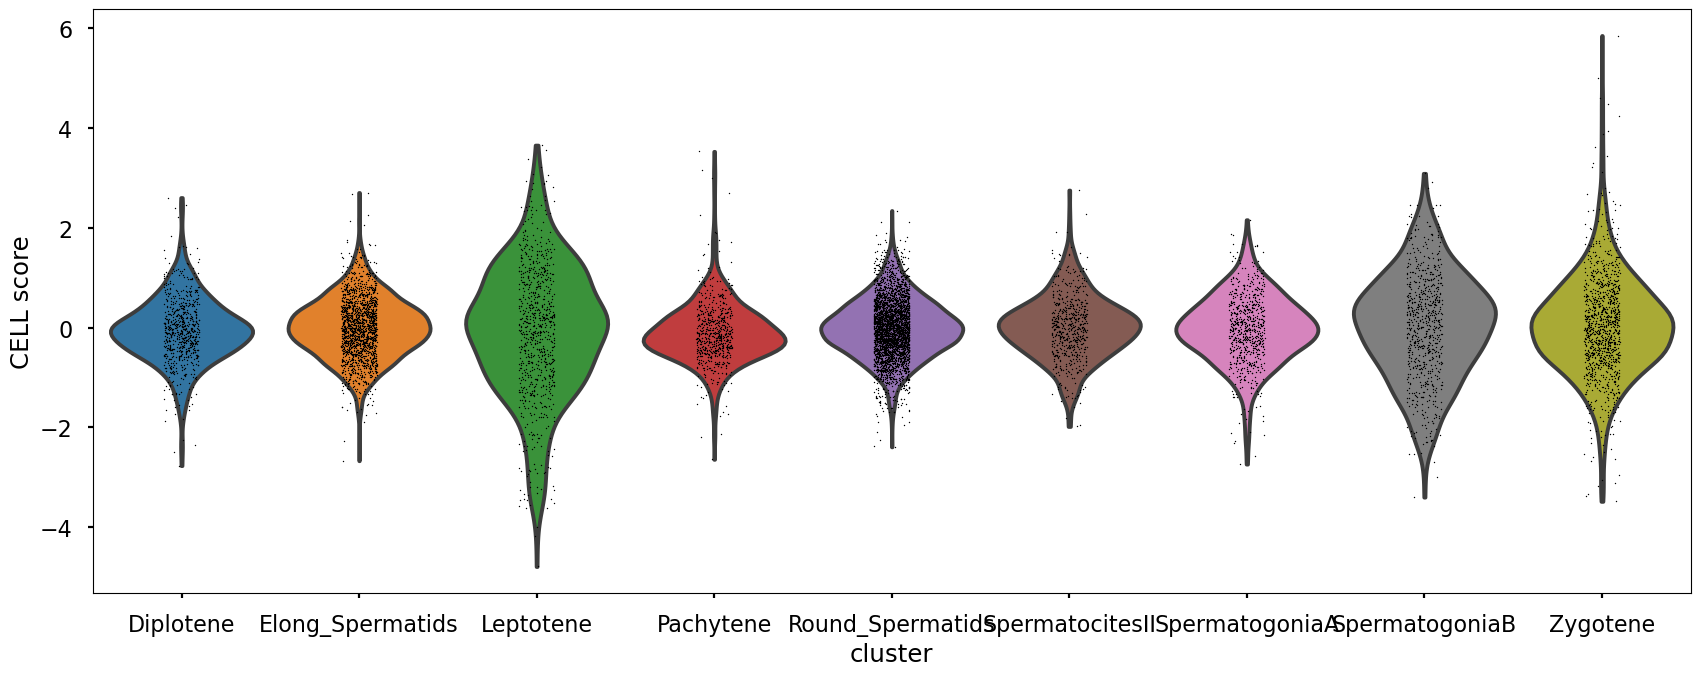

In [34]:
plt.rcParams['figure.figsize']=(16,8)
sc.pl.violin(adata, 
             groupby='spermatogenesis', keys=f'SDA_cellscore_C{comp}',
             title=f'CELLS score for SDA component C{comp}',
             xlabel='cluster', ylabel='CELL score')

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'SpermatogoniaA'),
  Text(1, 0, 'SpermatogoniaB'),
  Text(2, 0, 'Leptotene'),
  Text(3, 0, 'Zygotene'),
  Text(4, 0, 'Pachytene'),
  Text(5, 0, 'Diplotene'),
  Text(6, 0, 'SpermatocitesII'),
  Text(7, 0, 'Round_Spermatids'),
  Text(8, 0, 'Elong_Spermatids')])

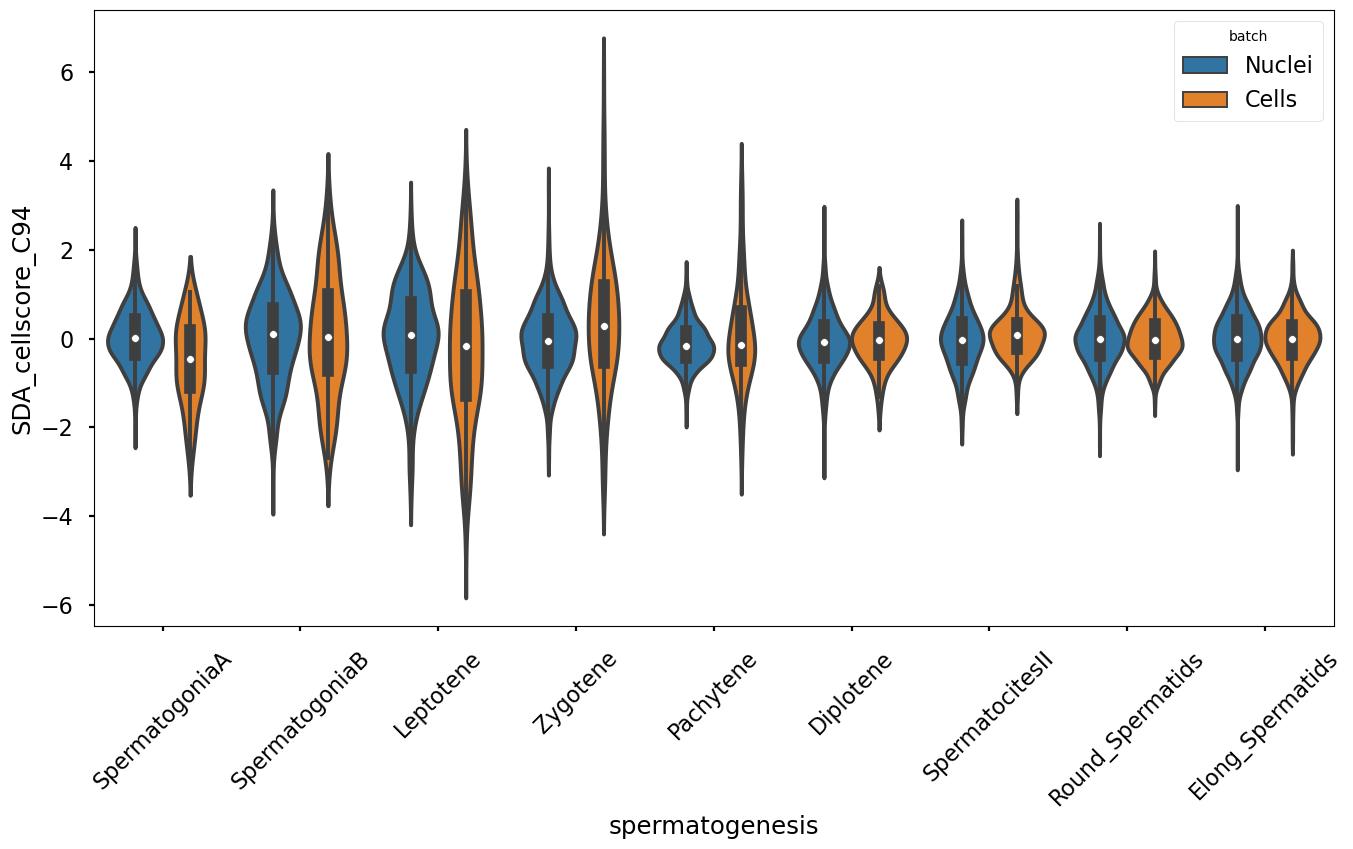

In [35]:
plt.rcParams['figure.figsize']=(16,8)
sns.violinplot(x='spermatogenesis', y=f'SDA_cellscore_C{comp}', hue='batch', data=adata.obs, 
               order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids'])
plt.xticks(rotation=45)

#### Cell scores by pseudotimes and relative threshold lines

In [36]:
score_neg = -2 #min( -2, np.quantile(A[int(comp)], .1) )
score_pos = 2 #max( +2, np.quantile(A[int(comp)], .9) )

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C94')

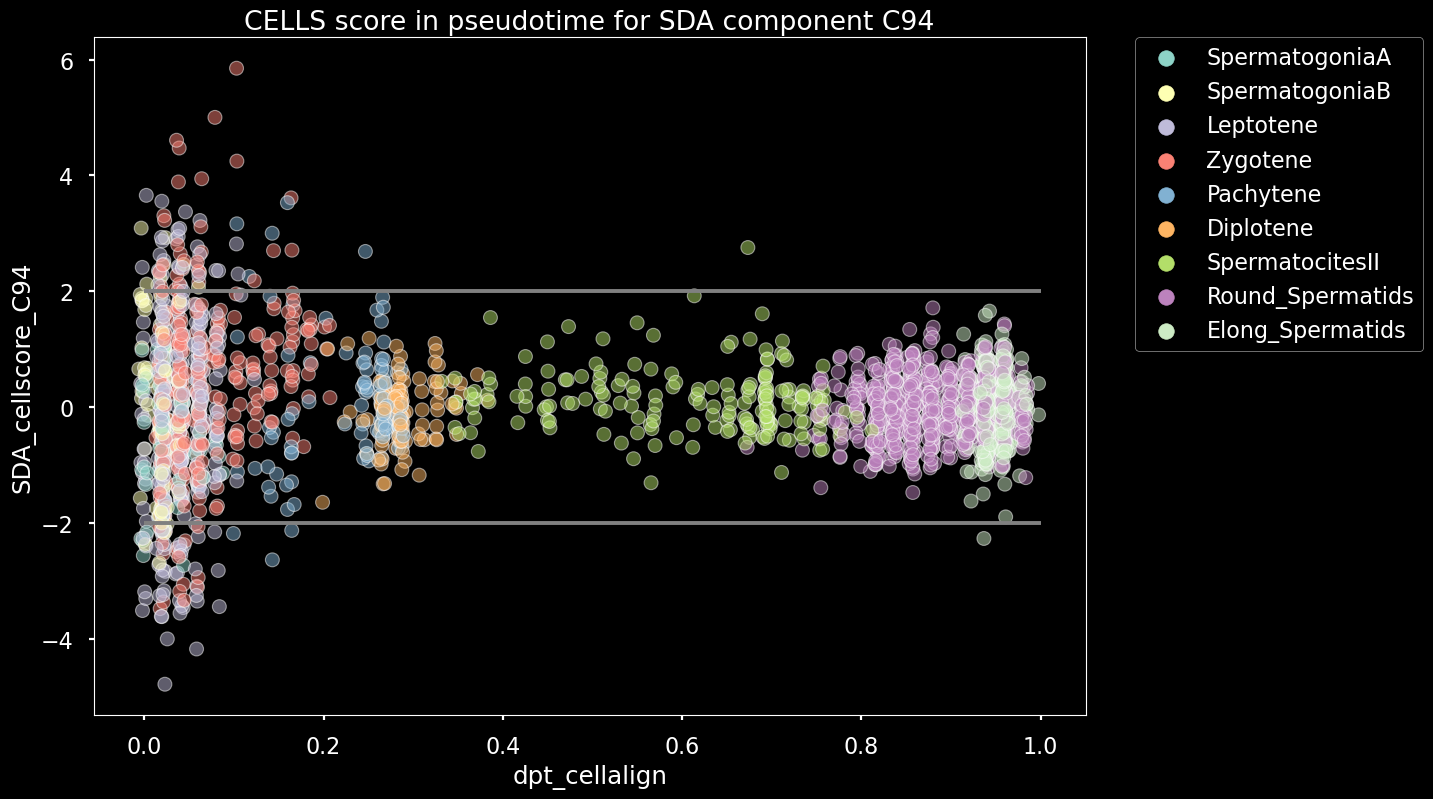

In [37]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.5, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C94')

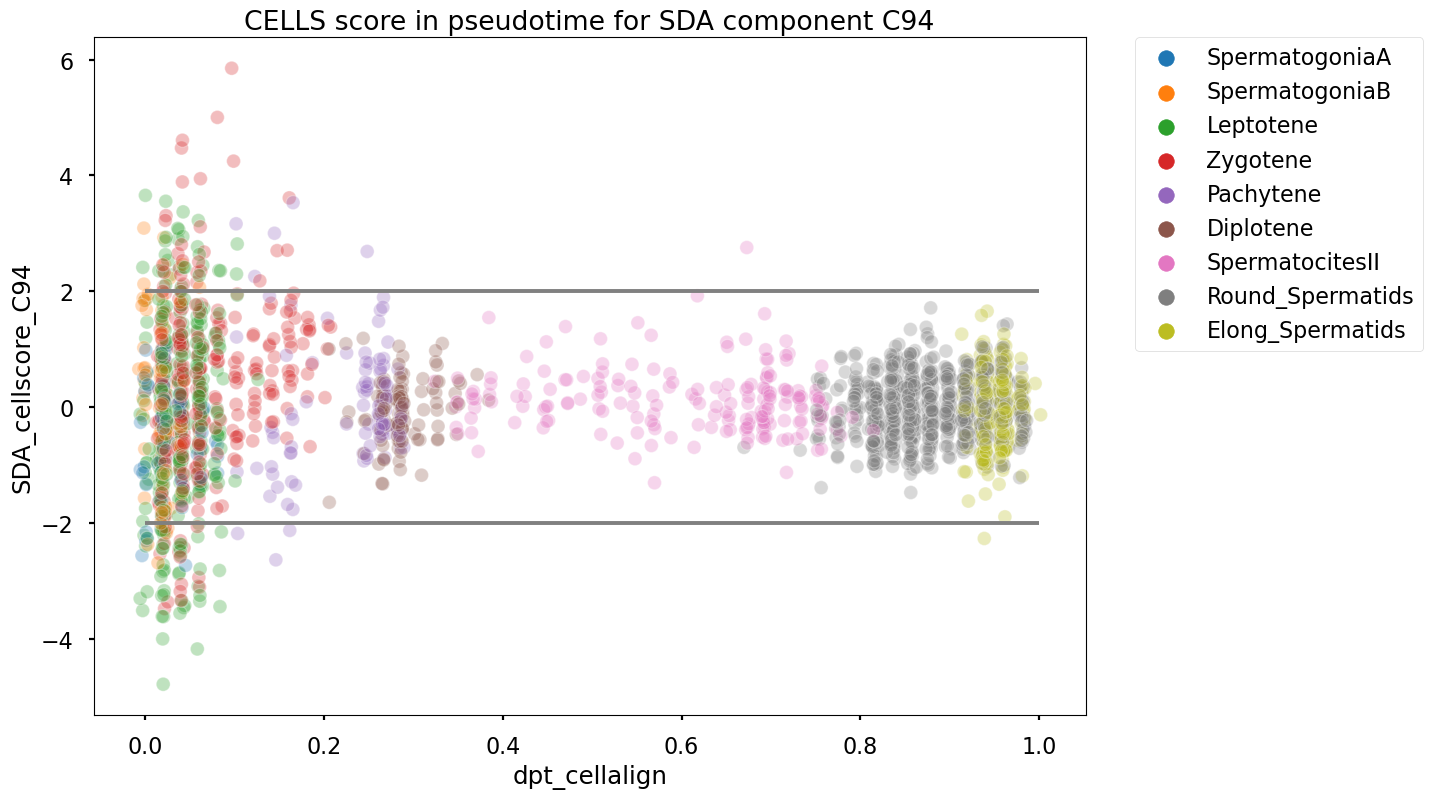

In [38]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata[adata.obs['batch']=='Cells'].obs[f'SDA_cellscore_C{comp}'], 
           x=adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata[adata.obs['batch']=='Cells'].shape[0]),
           hue=adata[adata.obs['batch']=='Cells'].obs['spermatogenesis'],
           alpha=.3, ax=ax, s=100,
           hue_order=['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 'Pachytene', 
                      'Diplotene', 'SpermatocitesII', 'Round_Spermatids', 'Elong_Spermatids']
           )
plt.hlines(score_neg, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata[adata.obs['batch']=='Cells'].obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C94')

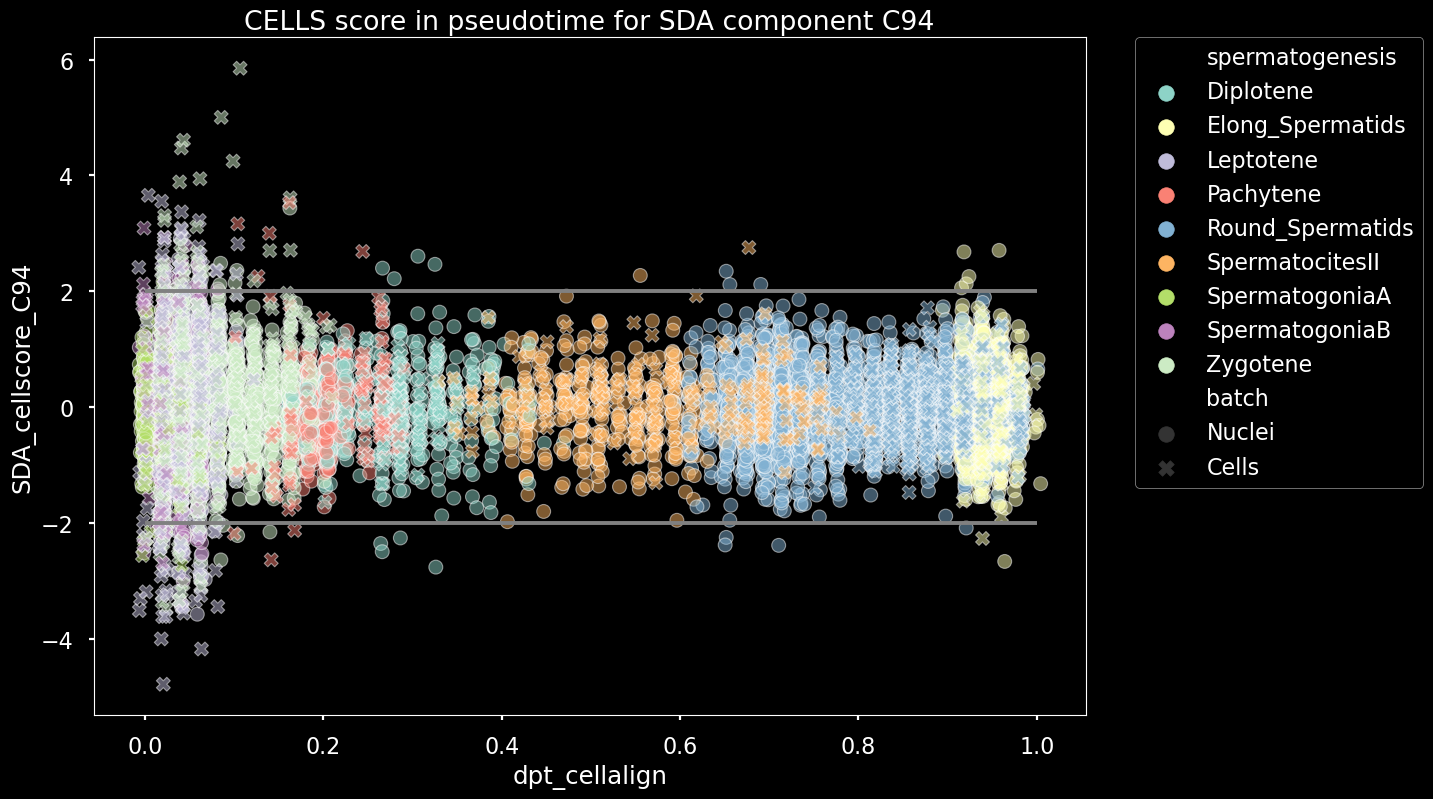

In [39]:
plt.rcParams['figure.figsize']=(16,8)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
fig, ax = plt.subplots(1)
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.5, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

Text(0.5, 1.0, 'CELLS score in pseudotime for SDA component C94')

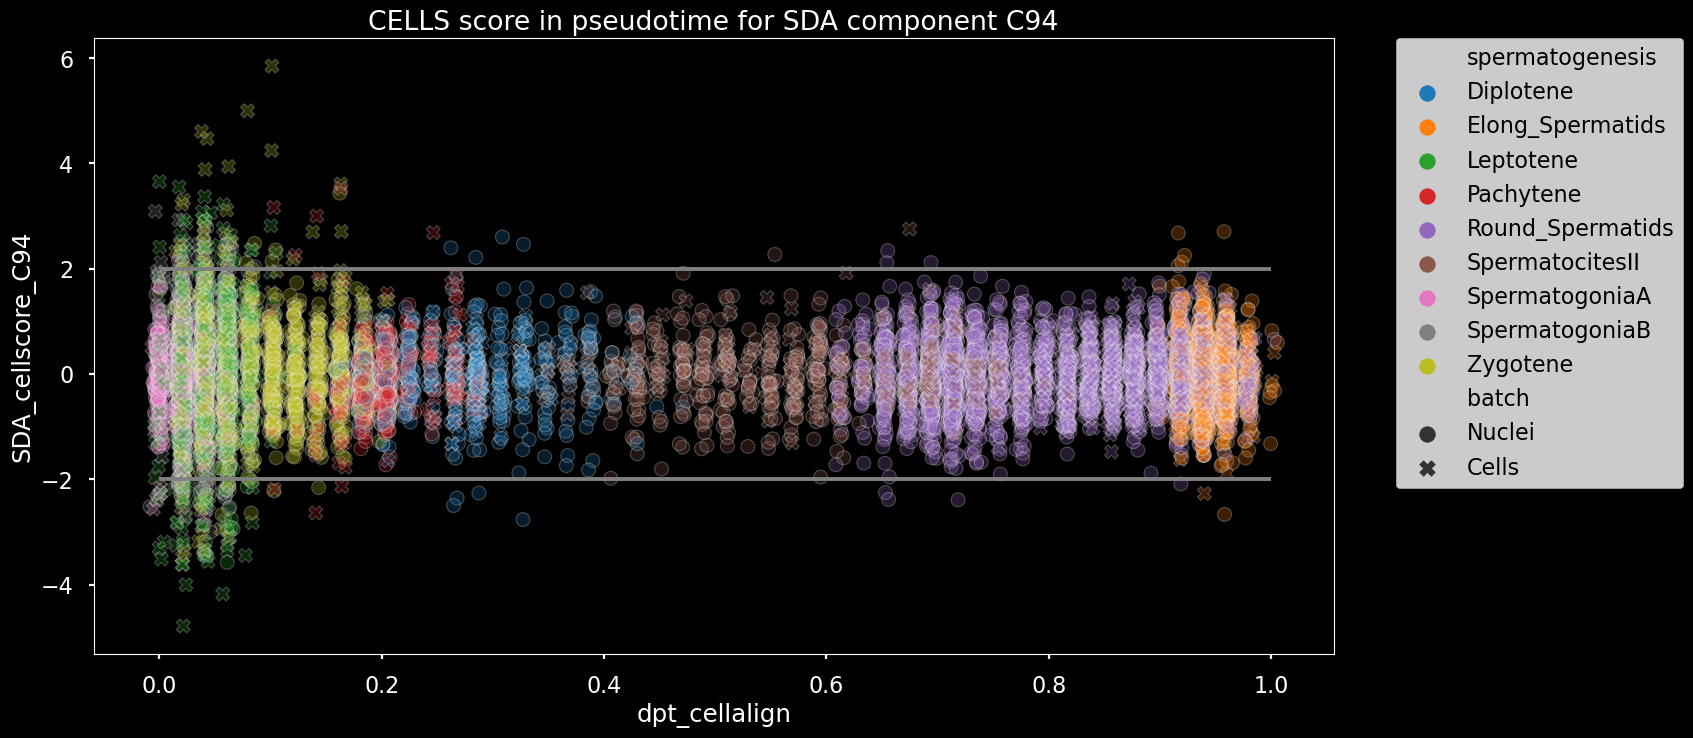

In [40]:
plt.rcParams['figure.figsize']=(16,8)
fig, ax = plt.subplots(1)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sns.scatterplot(y=adata.obs[f'SDA_cellscore_C{comp}'],
           x=adata.obs['dpt_cellalign']+
                    np.random.normal(0,.0025,adata.shape[0]),
           hue=adata.obs['spermatogenesis'],
           style=adata.obs['batch'],
           alpha=.25, ax=ax, s=100)
plt.hlines(score_neg, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.hlines(score_pos, xmin=0, xmax=np.max(adata.obs['dpt_cellalign']), colors=['gray'])
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
ax.set_title(f'CELLS score in pseudotime for SDA component C{comp}')

## Gene set enrichment analysis

In [41]:
import gseapy as gp

In [42]:
!mkdir -p ./enrichment

In [43]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [44]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [45]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,45/158,4.532988e-45,6.618162e-43,0,0,30.588756,3123.263323,RPL5;RPL30;MRPS15;RPL32;RPL34;RPLP1;RPL12;RPL1...
1,KEGG_2021_Human,Coronavirus disease,43/232,2.011108e-34,1.468108e-32,0,0,17.272415,1340.152971,RPL5;RPL30;RPL32;RPL34;RPLP1;RPL12;RPL11;RPL10...
146,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),26/52,4.415666e-34,4.239039e-32,0,0,71.802920,5514.660580,RPL5;RPL30;RPL32;RPL34;RPLP1;RPL12;RPL11;RPL10...
147,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),26/52,4.415666e-34,4.239039e-32,0,0,71.802920,5514.660580,RPL5;RPL30;RPL32;RPL34;RPLP1;RPL12;RPL11;RPL10...
148,GO_Cellular_Component_2023,Polysomal Ribosome (GO:0042788),15/28,9.684315e-21,6.197961e-19,0,0,79.704453,3673.082451,RPL30;RPL32;DHX9;RPL11;RPL10A;RPL6;RPS26;RPS28...
149,GO_Cellular_Component_2023,Ribosome (GO:0005840),19/61,2.106442e-20,1.011092e-18,0,0,31.647348,1433.836946,RPL30;RPL32;DHX9;RPL11;RPL13A;RPL10A;RPL6;RPS2...
150,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),16/41,3.234914e-19,1.242207e-17,0,0,44.338028,1887.696616,RPS8;RPS6;RPS15;RPS26;RPS14;RPS28;RPS15A;RPS27...
151,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),16/42,5.155834e-19,1.649867e-17,0,0,42.630553,1795.129421,RPS8;RPS6;RPS15;RPS26;RPS14;RPS28;RPS15A;RPS27...
152,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),24/387,5.056264e-09,1.386861e-07,0,0,4.632172,88.486695,RPL5;MDC1;RPL30;RPS8;RPL12;RPLP1;RPL22;RPL13A;...
153,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),24/395,7.531406e-09,1.807537e-07,0,0,4.530411,84.737648,RPL5;MDC1;RPL30;RPS8;RPL12;RPLP1;RPL22;RPL13A;...


In [46]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [47]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None)

In [48]:
table_pos = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [49]:
table_pos['Component'] = f'{comp}P'

In [50]:
table_pos['Batch diff'] = batch_effect_pos

In [51]:
table_pos['N cells'] = POSITIVE

In [52]:
table_pos

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Ribosome,45/158,6.618162e-43,30.588756,3123.263323,RPL5;RPL30;MRPS15;RPL32;RPL34;RPLP1;RPL12;RPL1...,94P,No,218
1,KEGG_2021_Human,Coronavirus disease,43/232,1.468108e-32,17.272415,1340.152971,RPL5;RPL30;RPL32;RPL34;RPLP1;RPL12;RPL11;RPL10...,94P,No,218
146,GO_Cellular_Component_2023,Large Ribosomal Subunit (GO:0015934),26/52,4.239039e-32,71.802920,5514.660580,RPL5;RPL30;RPL32;RPL34;RPLP1;RPL12;RPL11;RPL10...,94P,No,218
147,GO_Cellular_Component_2023,Cytosolic Large Ribosomal Subunit (GO:0022625),26/52,4.239039e-32,71.802920,5514.660580,RPL5;RPL30;RPL32;RPL34;RPLP1;RPL12;RPL11;RPL10...,94P,No,218
148,GO_Cellular_Component_2023,Polysomal Ribosome (GO:0042788),15/28,6.197961e-19,79.704453,3673.082451,RPL30;RPL32;DHX9;RPL11;RPL10A;RPL6;RPS26;RPS28...,94P,No,218
149,GO_Cellular_Component_2023,Ribosome (GO:0005840),19/61,1.011092e-18,31.647348,1433.836946,RPL30;RPL32;DHX9;RPL11;RPL13A;RPL10A;RPL6;RPS2...,94P,No,218
150,GO_Cellular_Component_2023,Cytosolic Small Ribosomal Subunit (GO:0022627),16/41,1.242207e-17,44.338028,1887.696616,RPS8;RPS6;RPS15;RPS26;RPS14;RPS28;RPS15A;RPS27...,94P,No,218
151,GO_Cellular_Component_2023,Small Ribosomal Subunit (GO:0015935),16/42,1.649867e-17,42.630553,1795.129421,RPS8;RPS6;RPS15;RPS26;RPS14;RPS28;RPS15A;RPS27...,94P,No,218
152,GO_Cellular_Component_2023,Focal Adhesion (GO:0005925),24/387,1.386861e-07,4.632172,88.486695,RPL5;MDC1;RPL30;RPS8;RPL12;RPLP1;RPL22;RPL13A;...,94P,No,218
153,GO_Cellular_Component_2023,Cell-Substrate Junction (GO:0030055),24/395,1.807537e-07,4.530411,84.737648,RPL5;MDC1;RPL30;RPS8;RPL12;RPLP1;RPL22;RPL13A;...,94P,No,218


In [53]:
table_pos.to_csv(f'enrichment/enrichr_C{comp}P.csv', header=False, index_label=False, index=None, sep='\t')

In [54]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [55]:
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=genes, # or "./tests/data/gene_list.txt",
                 gene_sets=['KEGG_2021_Human', 'GO_Cellular_Component_2023', 'Human_Gene_Atlas'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )

In [56]:
enr.results[enr.results['Adjusted P-value']<.001]

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,16/171,8.156961e-09,1.566137e-06,0,0,7.003943,130.444188,PDIA3;BCAP31;ERO1B;HSPA5;UBE2J2;PDIA6;DDOST;DN...
192,GO_Cellular_Component_2023,Endoplasmic Reticulum Membrane (GO:0005789),38/801,5.176197e-10,1.066297e-07,0,0,3.544842,75.795029,ERO1B;TMED10;ARL6IP1;GPAA1;CCDC47;PIGP;MIA2;EM...
193,GO_Cellular_Component_2023,Secretory Granule Membrane (GO:0030667),17/279,1.415320e-06,1.457779e-04,0,0,4.393675,59.174697,CD63;TMED10;GAA;APLP2;ATP6AP2;NDUFC2;DDOST;SER...


In [57]:
table_neg = enr.results[enr.results['Adjusted P-value']<.001][ ['Gene_set', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'Genes' ] ]

In [58]:
table_neg['Component'] = f'{comp}N'

In [59]:
table_neg['Batch diff'] = batch_effect_neg

In [60]:
table_neg['N cells'] = NEGATIVE

In [61]:
table_neg

,Gene_set,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,Genes,Component,Batch diff,N cells
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,16/171,1.566137e-06,7.003943,130.444188,PDIA3;BCAP31;ERO1B;HSPA5;UBE2J2;PDIA6;DDOST;DN...,94N,No,249
192,GO_Cellular_Component_2023,Endoplasmic Reticulum Membrane (GO:0005789),38/801,1.066297e-07,3.544842,75.795029,ERO1B;TMED10;ARL6IP1;GPAA1;CCDC47;PIGP;MIA2;EM...,94N,No,249
193,GO_Cellular_Component_2023,Secretory Granule Membrane (GO:0030667),17/279,1.457779e-04,4.393675,59.174697,CD63;TMED10;GAA;APLP2;ATP6AP2;NDUFC2;DDOST;SER...,94N,No,249


In [62]:
table_neg.to_csv(f'enrichment/enrichr_C{comp}N.csv', header=False, index_label=False, index=None, sep='\t')

## Plot genes average expression for positive and negative module

In [63]:
!mkdir -p ./plots

In [64]:
adata.layers

Layers with keys: SCT_counts, correct_counts, raw_counts, scaled_counts, spliced, unspliced

In [65]:
genes = list( adata[:,adata.var[f'sda_pos_C{comp}']].var_names )

In [66]:
adata.obs[f'module_pos_C{comp}'] = np.array( np.mean(adata[:,genes].layers['scaled_counts'], 1) )

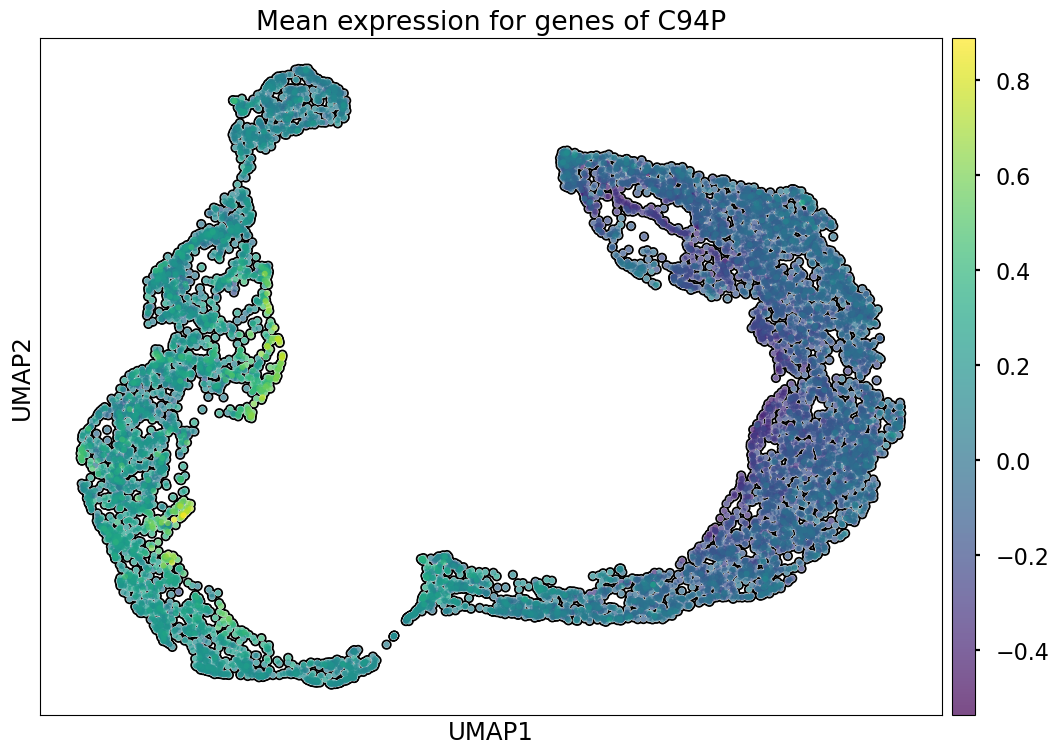

In [67]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}P_white.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

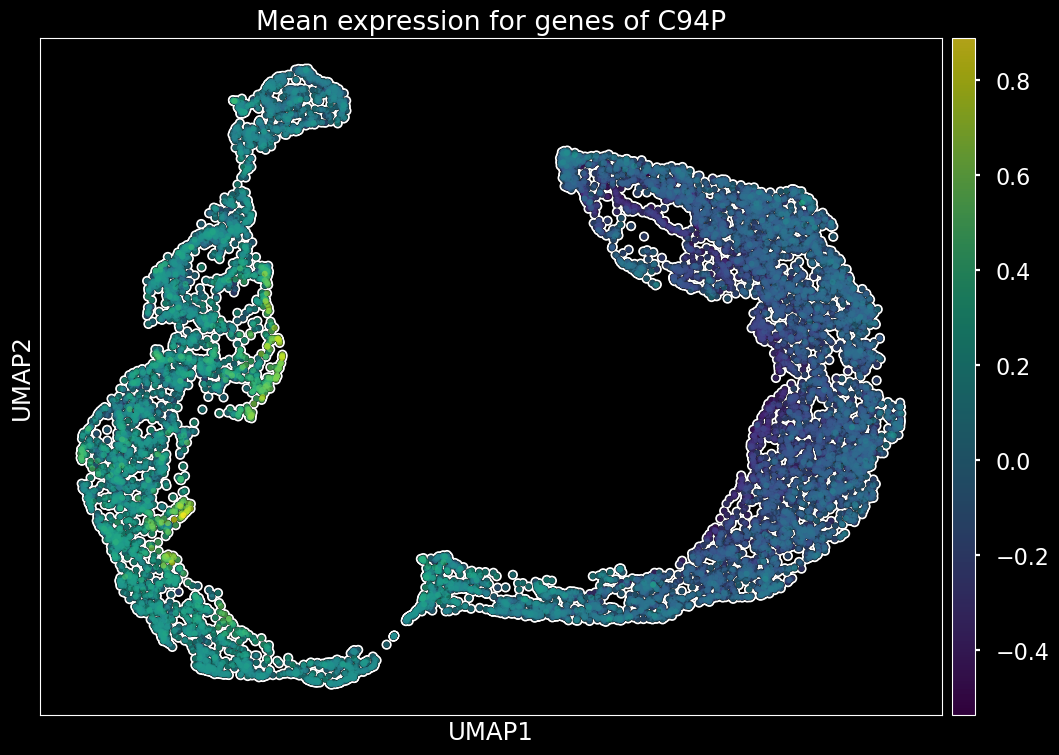

In [68]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_pos_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}P_dark.png',
           title=f'Mean expression for genes of C{comp}P', size=75)

In [69]:
genes = list( adata[:,adata.var[f'sda_neg_C{comp}']].var_names )

In [70]:
adata.obs[f'module_neg_C{comp}'] = np.array( np.mean(adata[:,genes].layers['SCT_counts'], 1) )

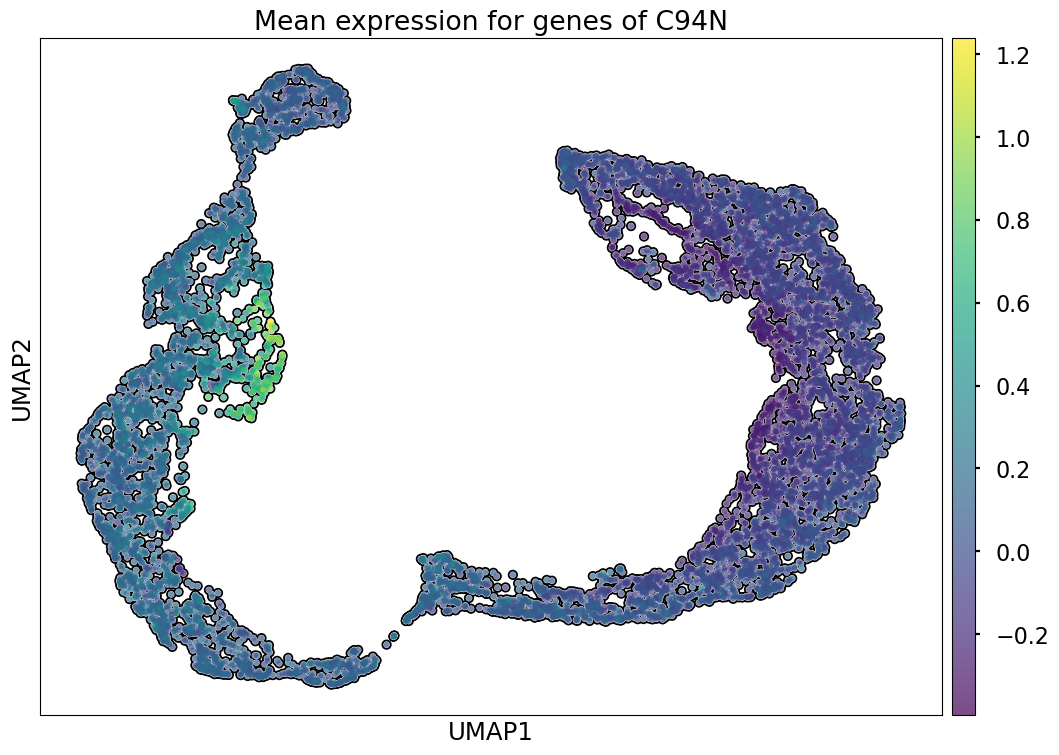

In [71]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('default')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, 
           save=f'genes_C{comp}N_white.png',
           title=f'Mean expression for genes of C{comp}N', size=75)

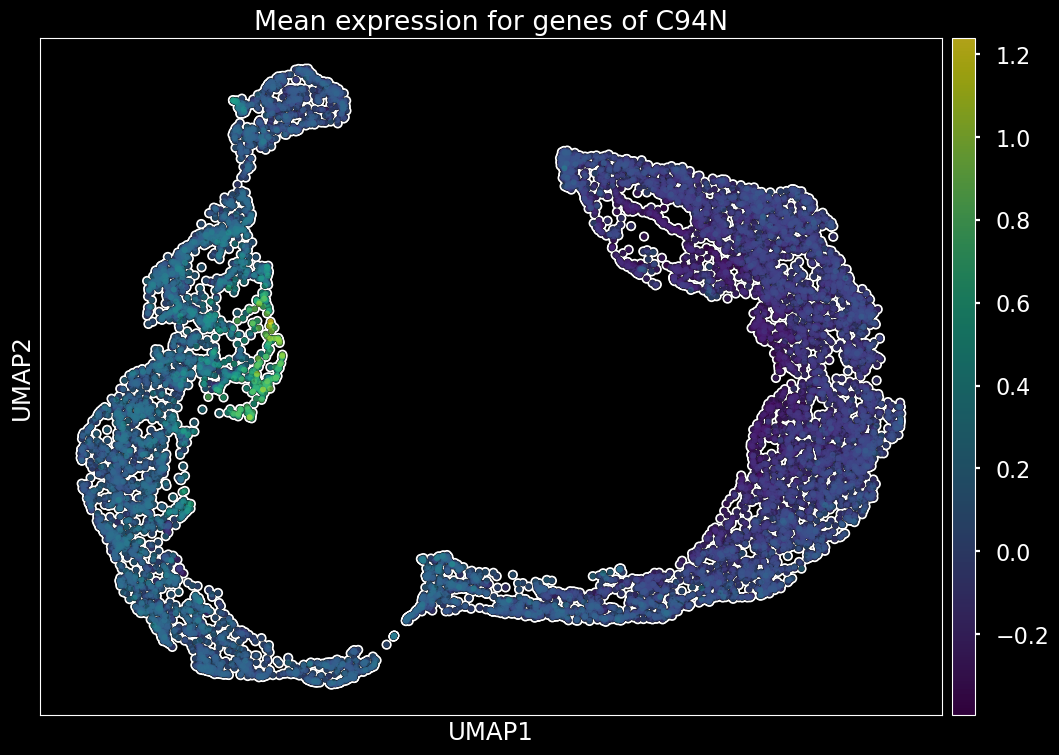

In [72]:
plt.rcParams['figure.figsize']=(7,7)
plt.style.use('dark_background')
plt.style.use('seaborn-v0_8-poster')
sc.pl.umap(adata, color=[f'module_neg_C{comp}'], 
           add_outline=True, outline_color=['white','black'],
           save=f'genes_C{comp}N_dark.png',
           title=f'Mean expression for genes of C{comp}N', size=75)